## import library

In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## read of data

In [102]:
import kagglehub

path = kagglehub.dataset_download("saurabh00007/iriscsv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'iriscsv' dataset.
Path to dataset files: /kaggle/input/iriscsv


In [103]:
path

'/kaggle/input/iriscsv'

In [104]:
df = pd.read_csv(path+"/Iris.csv")

In [105]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


## pre processing of data

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [107]:
df.drop("Id",axis=1,inplace=True)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [109]:
df.duplicated().sum()

np.int64(3)

In [110]:
df=df.drop_duplicates()

In [111]:
df.duplicated().sum()

np.int64(0)

In [112]:
df.isnull().sum().sort_values(ascending=False)

,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


## visualization

<Axes: ylabel='SepalLengthCm'>

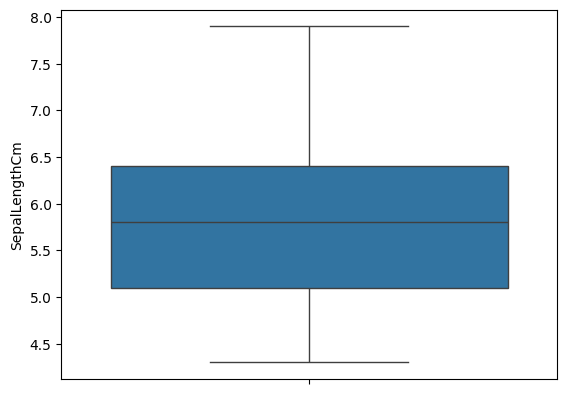

In [113]:
sns.boxplot(df["SepalLengthCm"])

<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

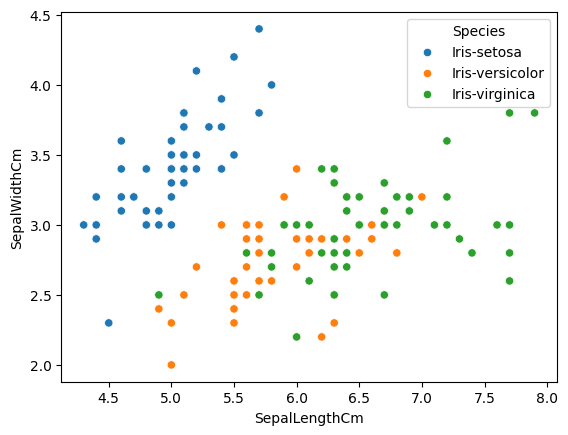

In [114]:
sns.scatterplot(data=df,x="SepalLengthCm",y="SepalWidthCm",hue="Species")

<Axes: >

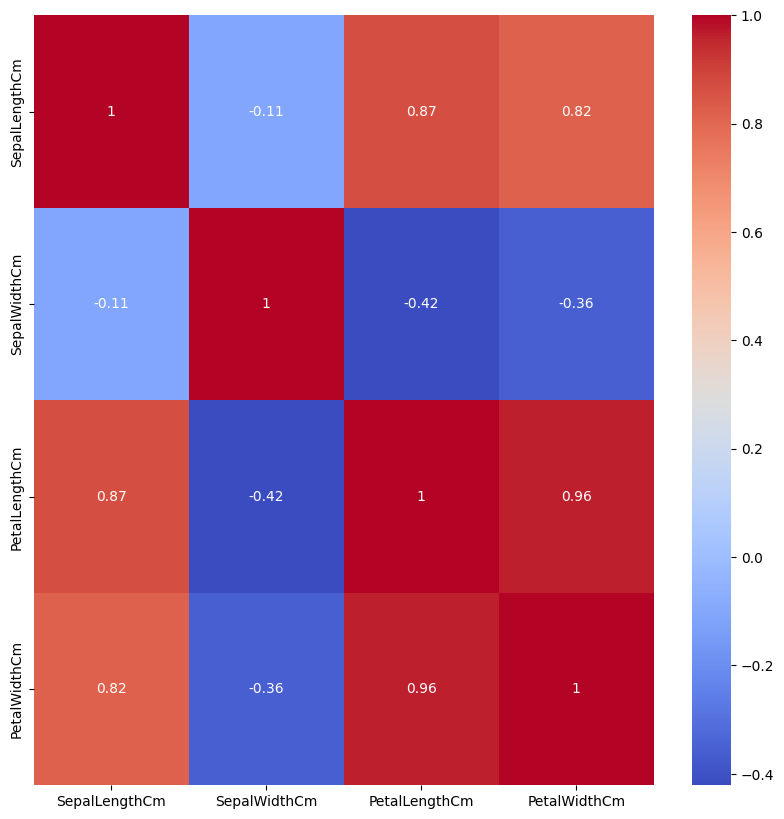

In [115]:
plt.figure(figsize=(10,10))
df_corr =df.select_dtypes(include=[np.number])
sns.heatmap(df_corr.corr(),annot=True,cmap="coolwarm")


In [116]:
px.bar(df,x="SepalLengthCm",y="SepalWidthCm",color="Species")

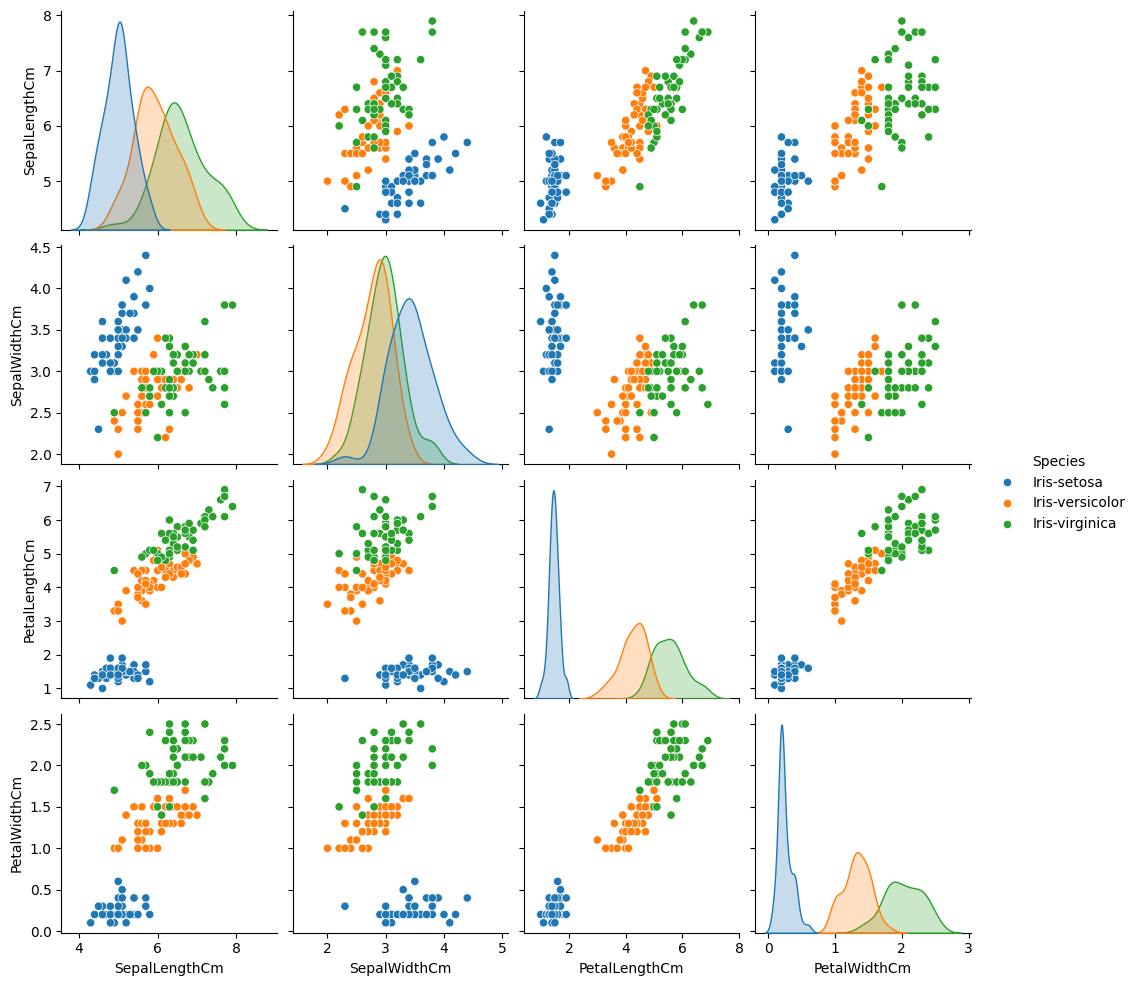

In [117]:
sns.pairplot(df,hue="Species")

In [118]:
px.bar(df,x="Species")

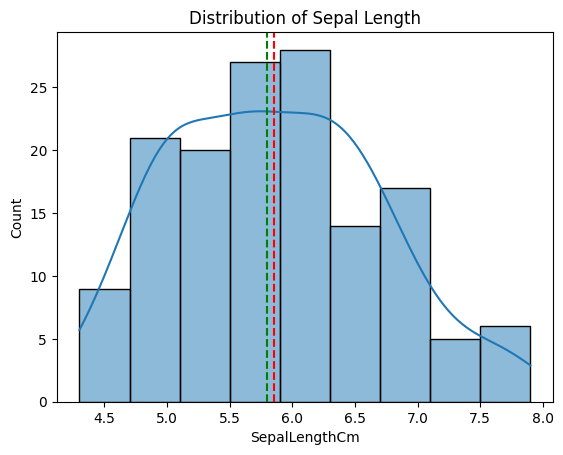

In [119]:
df = pd.read_csv(path + "/Iris.csv")
df.drop("Id", axis=1, inplace=True)
df = df.drop_duplicates()

sns.histplot(data=df,x="SepalLengthCm",kde=True)
plt.axvline(df["SepalLengthCm"].mean(),color="red",linestyle="--")
plt.axvline(df["SepalLengthCm"].median(),color="green",linestyle="--")
plt.title("Distribution of Sepal Length")
plt.show()

## split data

In [120]:
x=df.drop("Species",axis=1)
y=df["Species"]

In [121]:
from sklearn.model_selection import train_test_split

In [122]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

## scaling

In [123]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

## encoding

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  147 non-null    float64
 1   SepalWidthCm   147 non-null    float64
 2   PetalLengthCm  147 non-null    float64
 3   PetalWidthCm   147 non-null    float64
 4   Species        147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.9+ KB


In [125]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
cols=["Species"]
for col in cols:
  df[col]=le.fit_transform(df[col])


In [126]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [127]:
df["Species"]

,Species
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


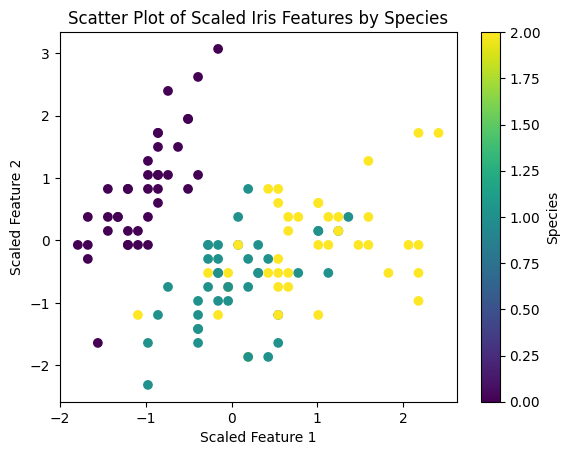

In [128]:
y_train_encoded = le.transform(y_train)

plt.scatter(
    x_train[:,0],
    x_train[:,1],
    c=y_train_encoded,
    cmap='viridis'
)

plt.colorbar(label="Species")
plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.title("Scatter Plot of Scaled Iris Features by Species")
plt.show()

In [129]:
!pip install xgboost lightgbm catboost

In [130]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB,CategoricalNB,BernoulliNB
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import  HistGradientBoostingClassifier
import xgboost as xgb
from xgboost import  XGBClassifier
from catboost import  CatBoostClassifier
import lightgbm as lgb
from lightgbm import  LGBMClassifier

In [134]:
models={
    "logistic regression":LogisticRegression(class_weight='balanced', random_state=42, max_iter=35),
    "GaussianNB":GaussianNB(),
    "BernoulliNB":BernoulliNB(),
    "knn" : KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=1),
    "svm":SVC(kernel="linear",C=50,gamma=5,probability=True,class_weight='balanced'),
    "Decision Tree":DecisionTreeClassifier(criterion='entropy',max_depth=15,class_weight='balanced',random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=70,criterion='entropy',max_depth=20,class_weight='balanced',random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=50, random_state=42,class_weight='balanced'),
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',max_depth=10,class_weight='balanced'),n_estimators=50, random_state=42),
    "ada bosting":AdaBoostClassifier(n_estimators=50,random_state=42),
    "Gradient boosting":GradientBoostingClassifier(n_estimators=60,learning_rate=0.1,random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42),
   # "XGBoost": XGBClassifier(n_estimators=50, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, iterations=50, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=40, learning_rate=0.1, random_state=42)
}

In [135]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score ,confusion_matrix,classification_report,roc_curve,auc
from sklearn.metrics import precision_recall_curve, average_precision_score


--- logistic regression ---
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


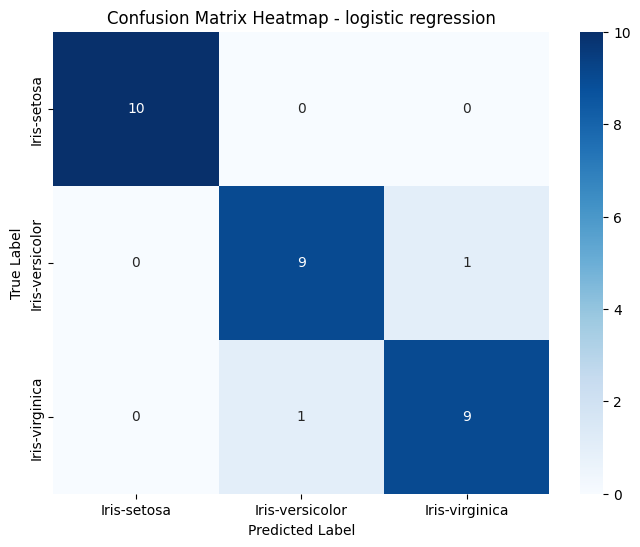

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



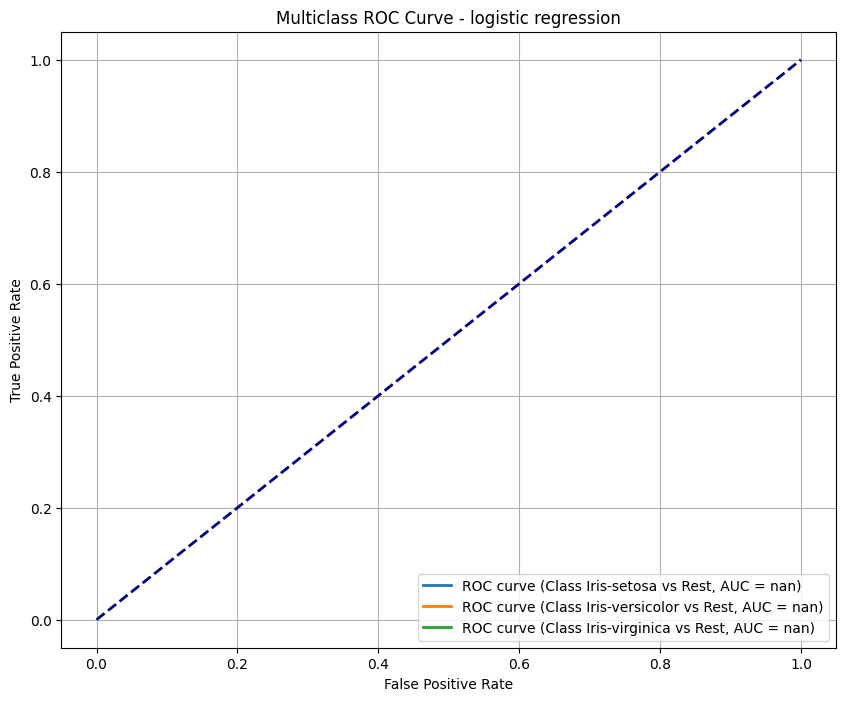

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



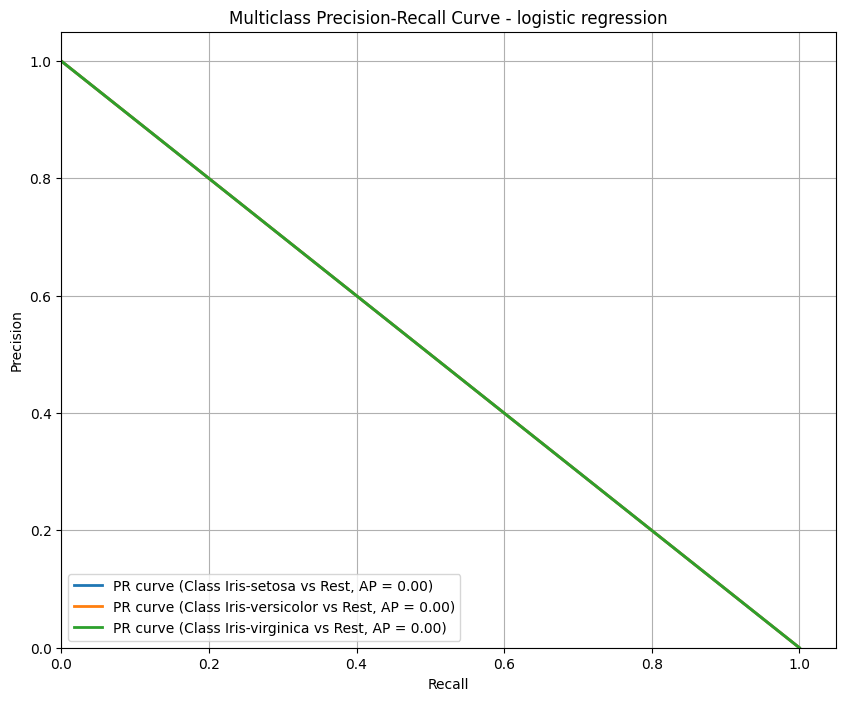


--- GaussianNB ---
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


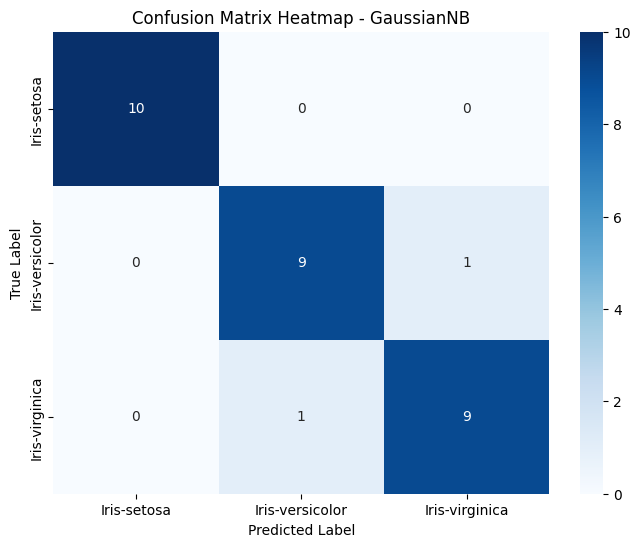

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



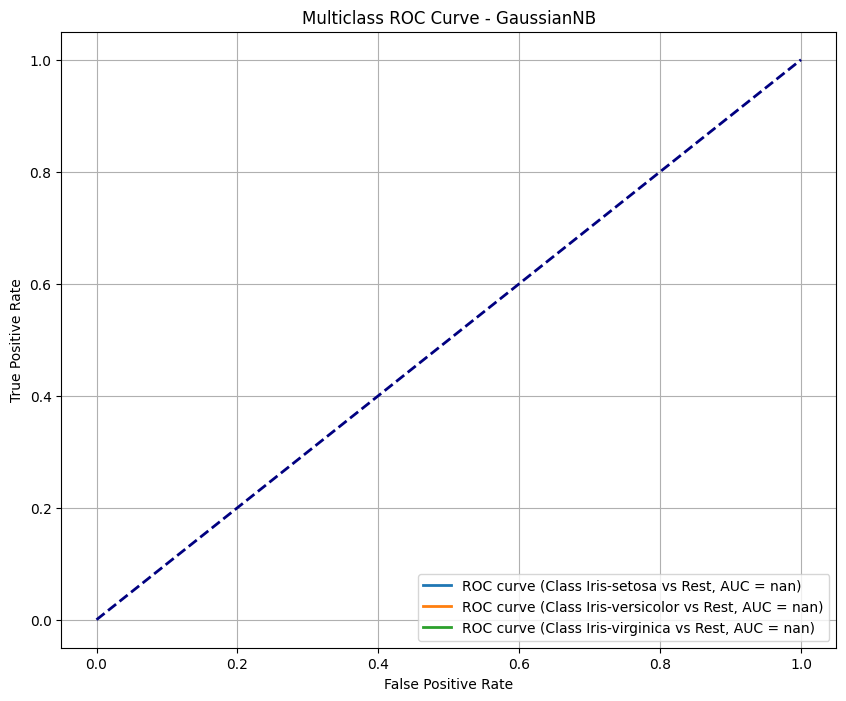

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



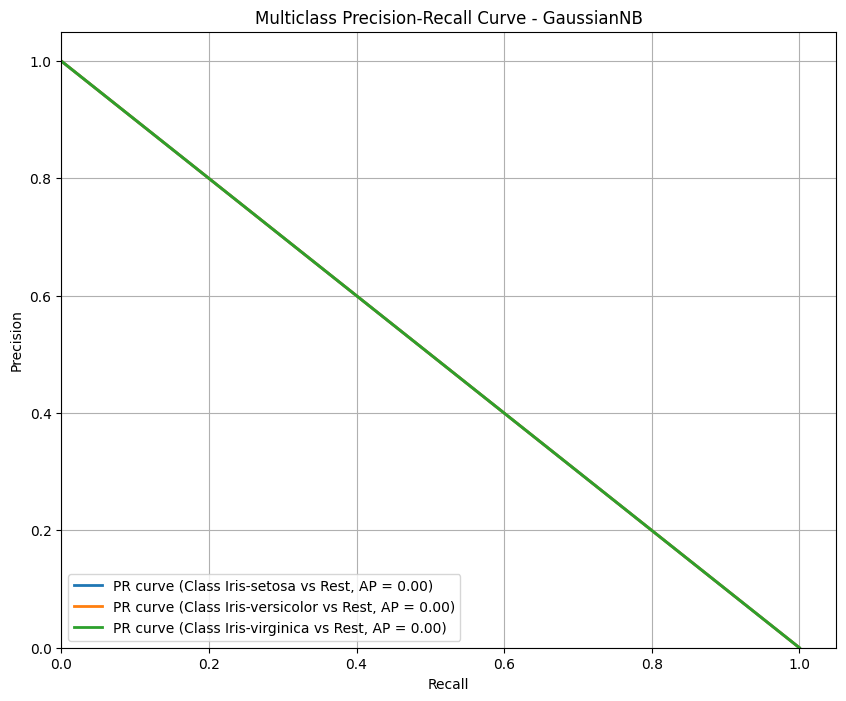


--- BernoulliNB ---
Confusion Matrix:
[[10  0  0]
 [ 1  2  7]
 [ 0  0 10]]


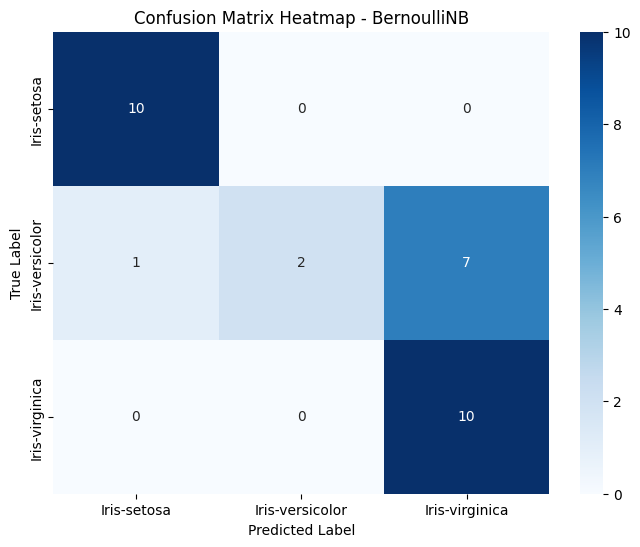

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       0.91      1.00      0.95        10
Iris-versicolor       1.00      0.20      0.33        10
 Iris-virginica       0.59      1.00      0.74        10

       accuracy                           0.73        30
      macro avg       0.83      0.73      0.68        30
   weighted avg       0.83      0.73      0.68        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



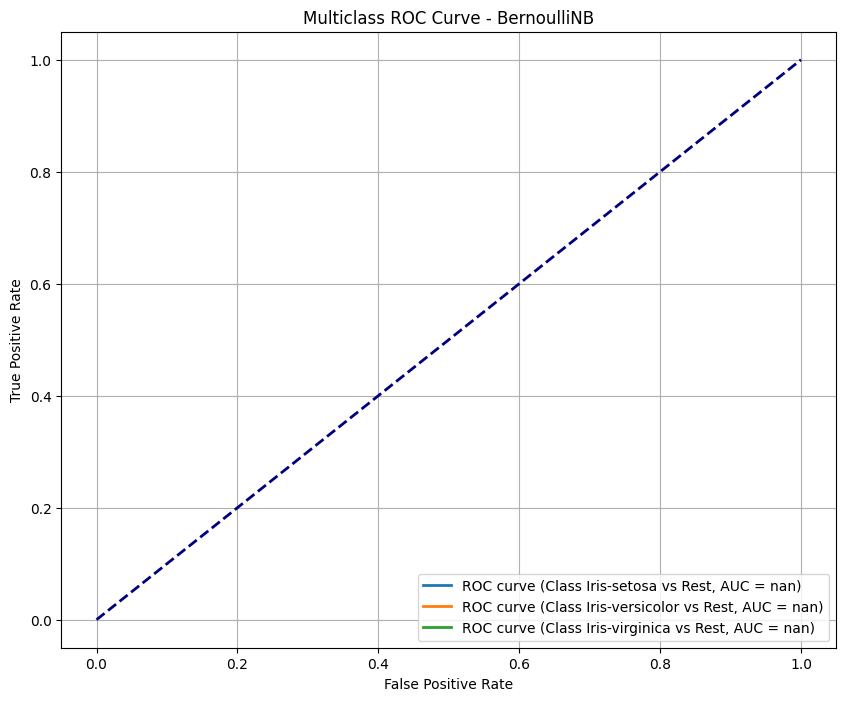

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



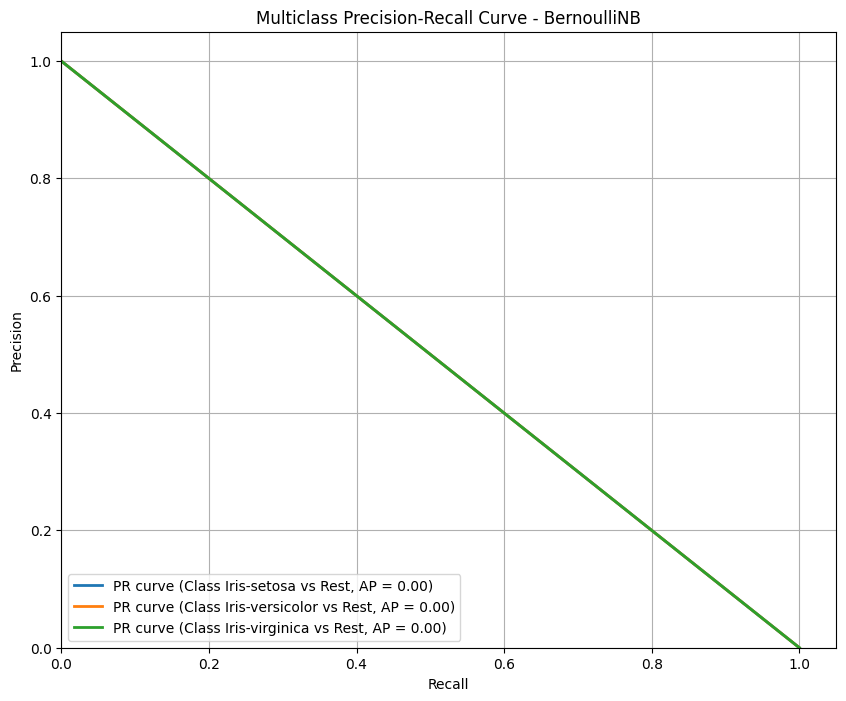


--- knn ---
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


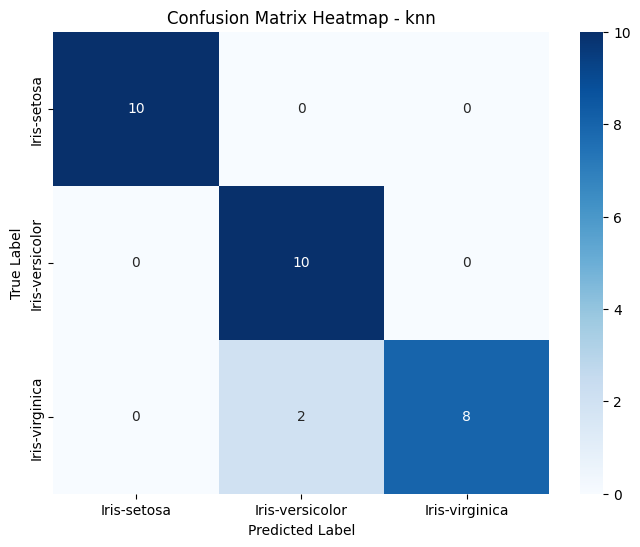

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



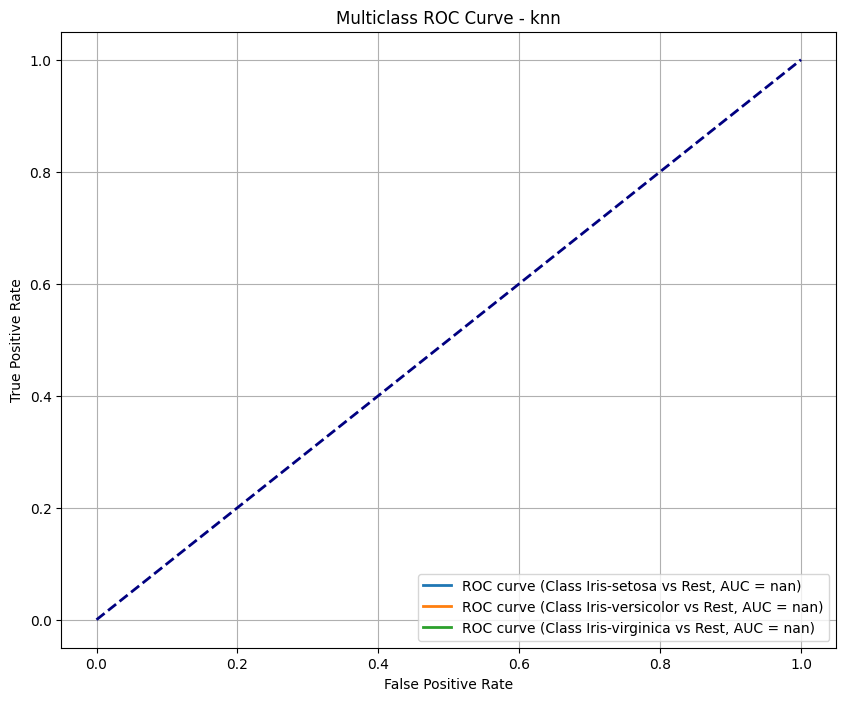

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



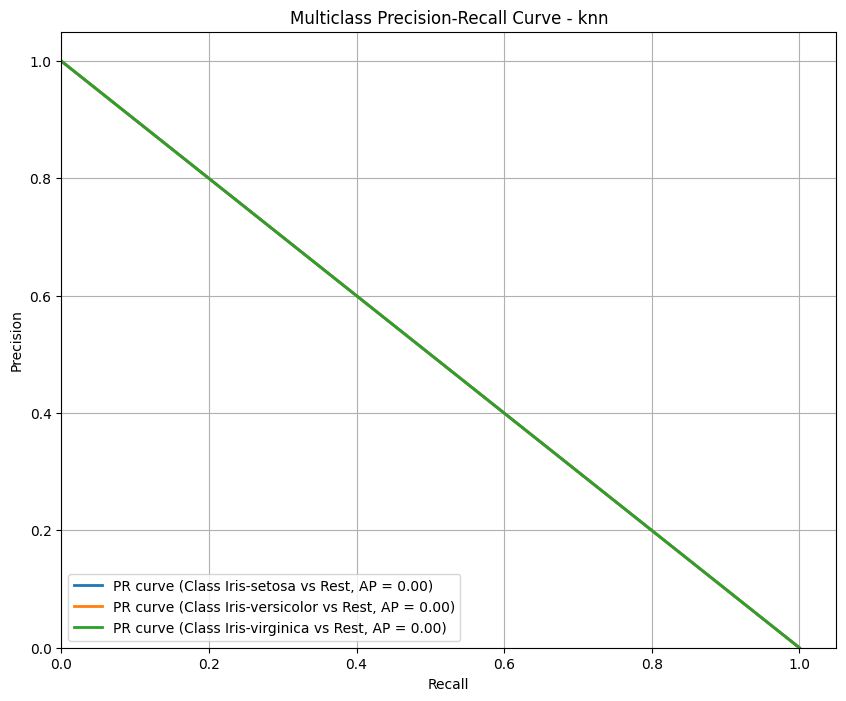


--- svm ---
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


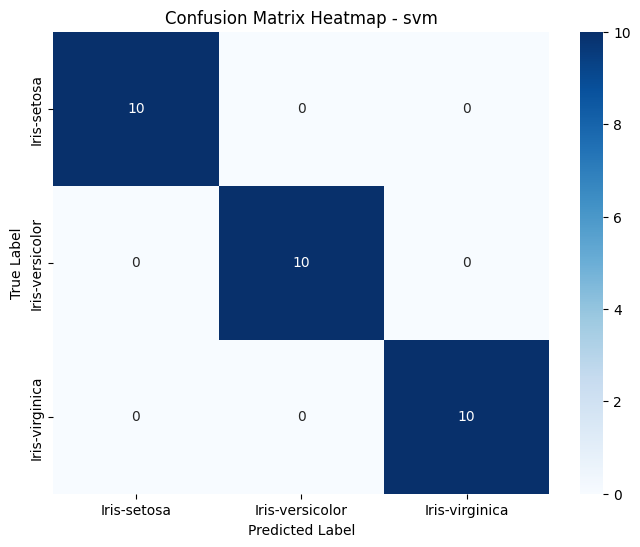

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



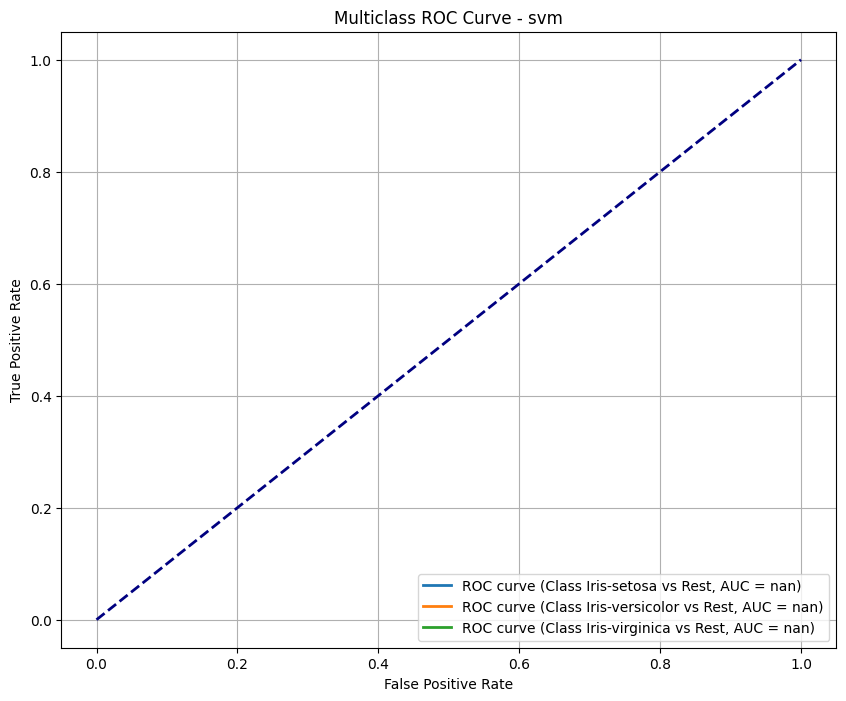

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



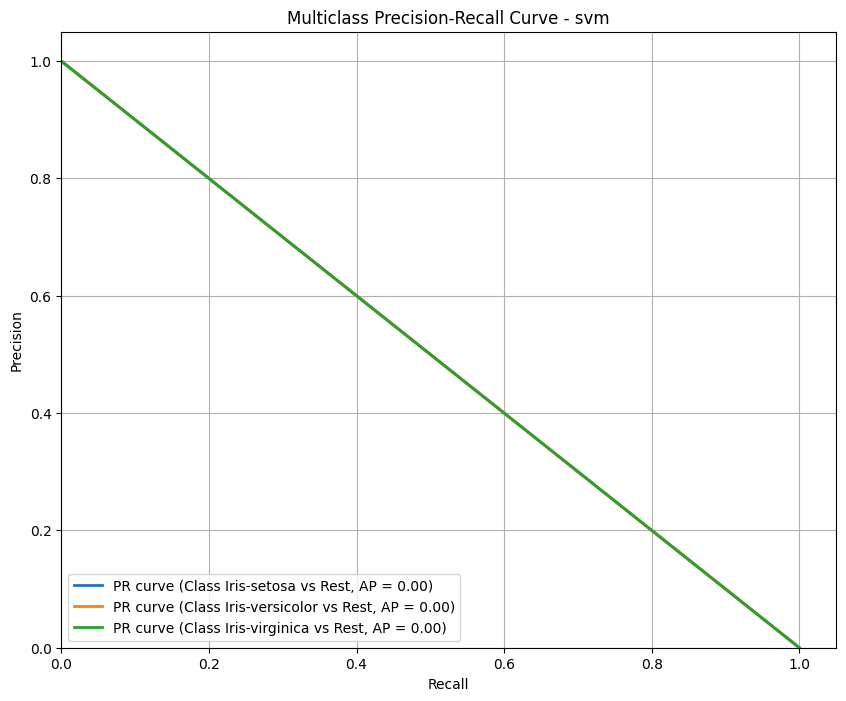


--- Decision Tree ---
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


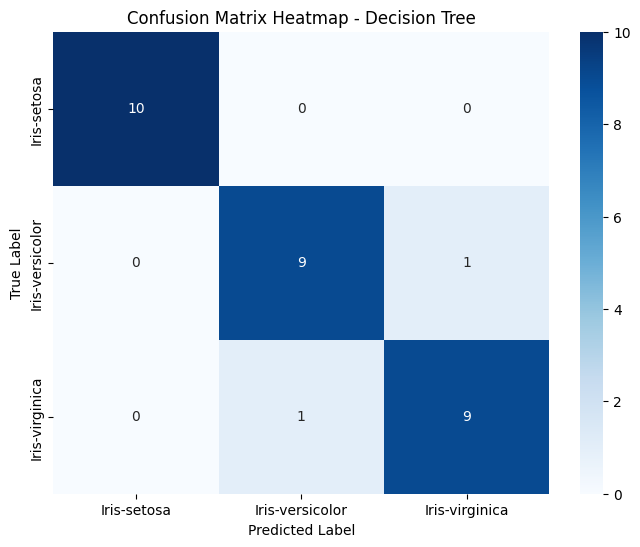

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



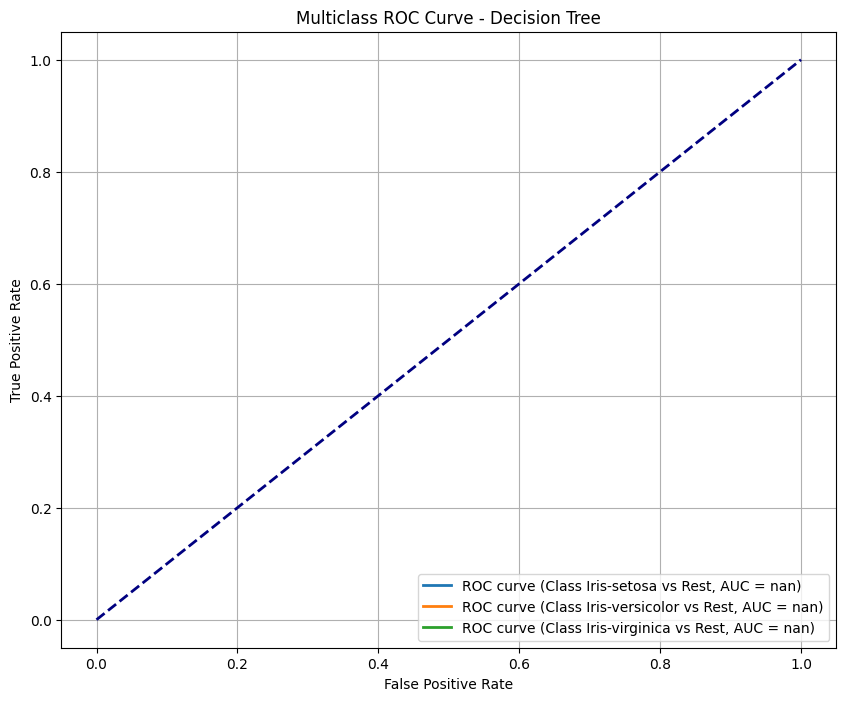

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



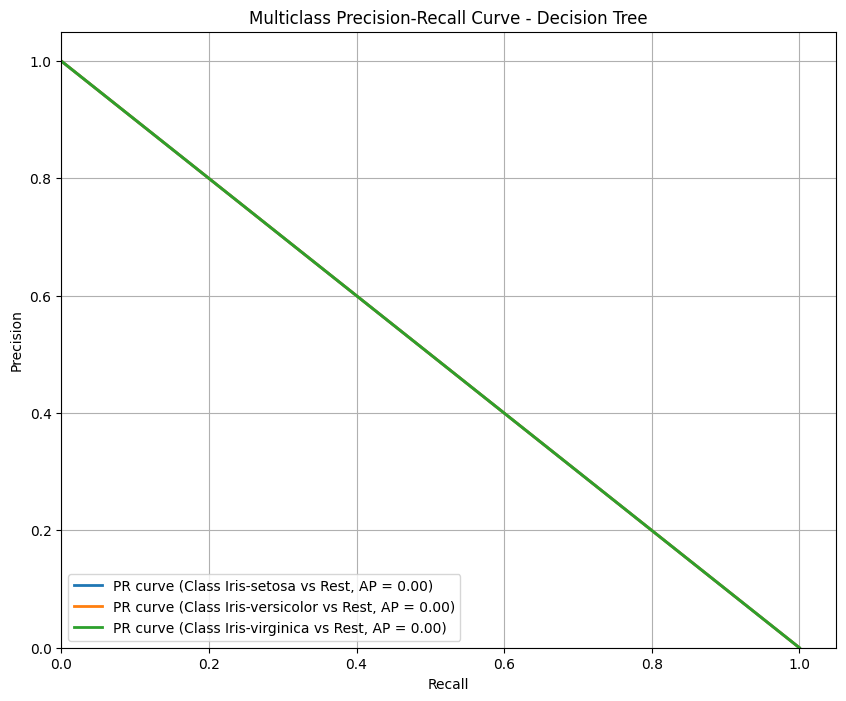


--- Random Forest ---
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


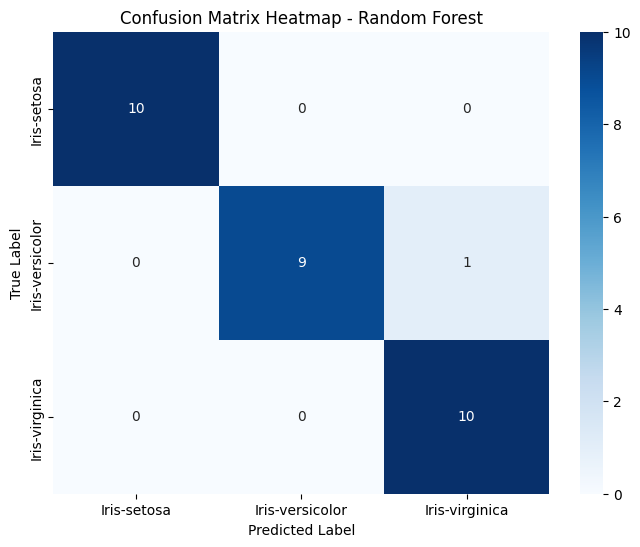

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



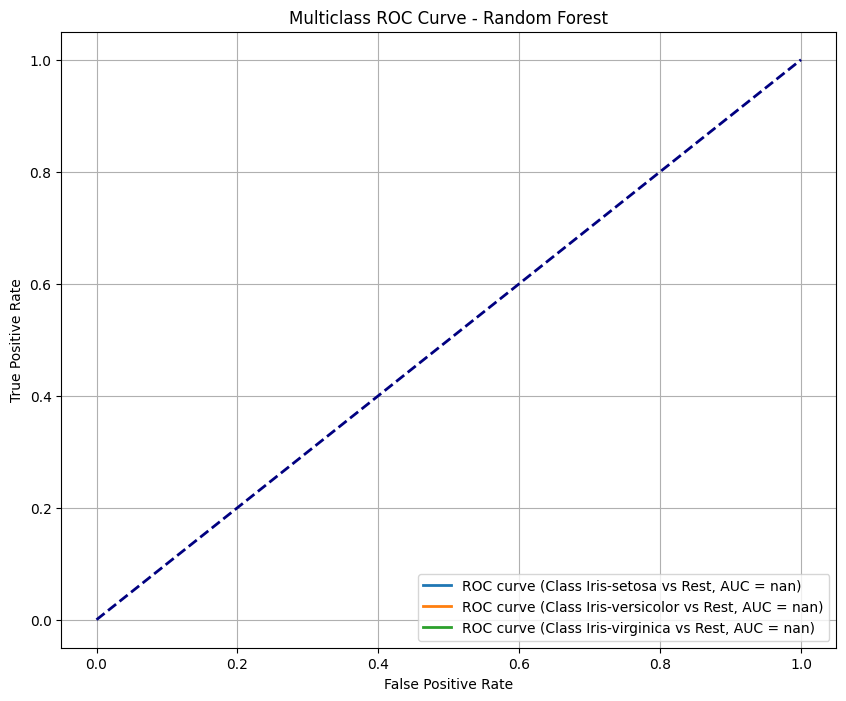

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



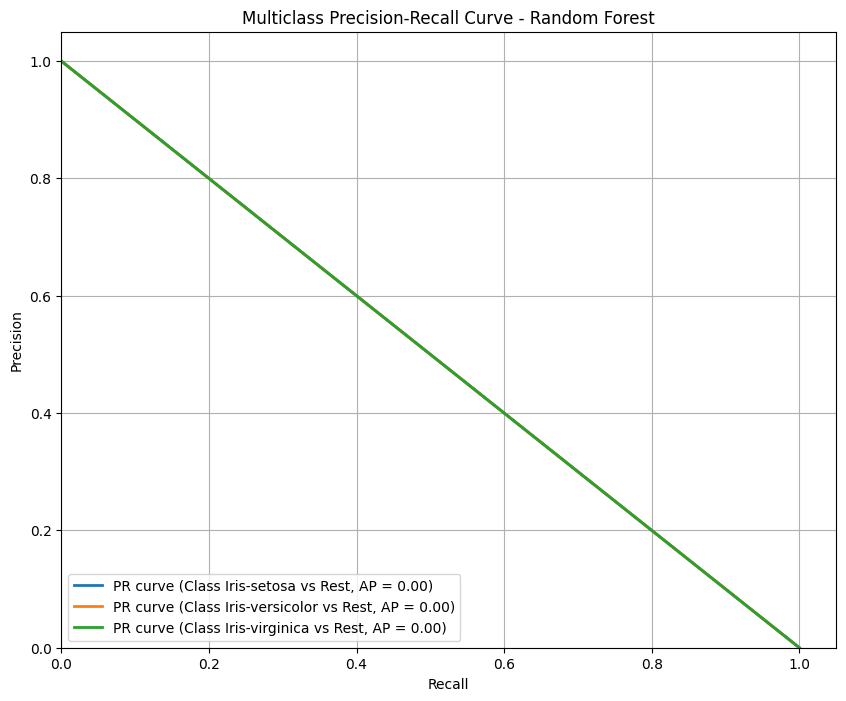


--- ExtraTrees ---
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


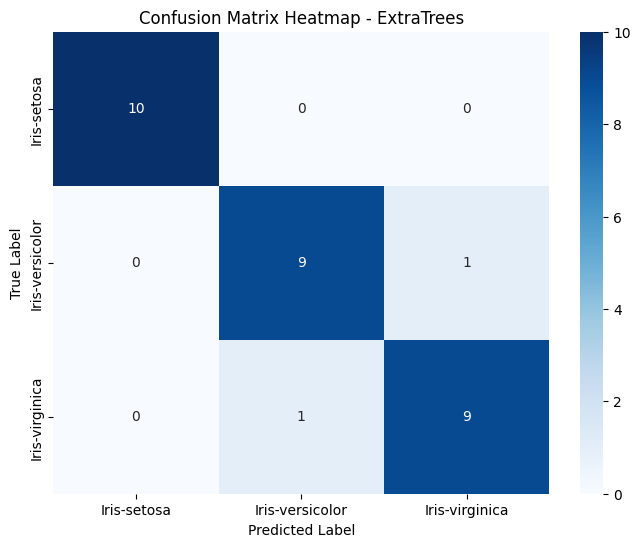

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



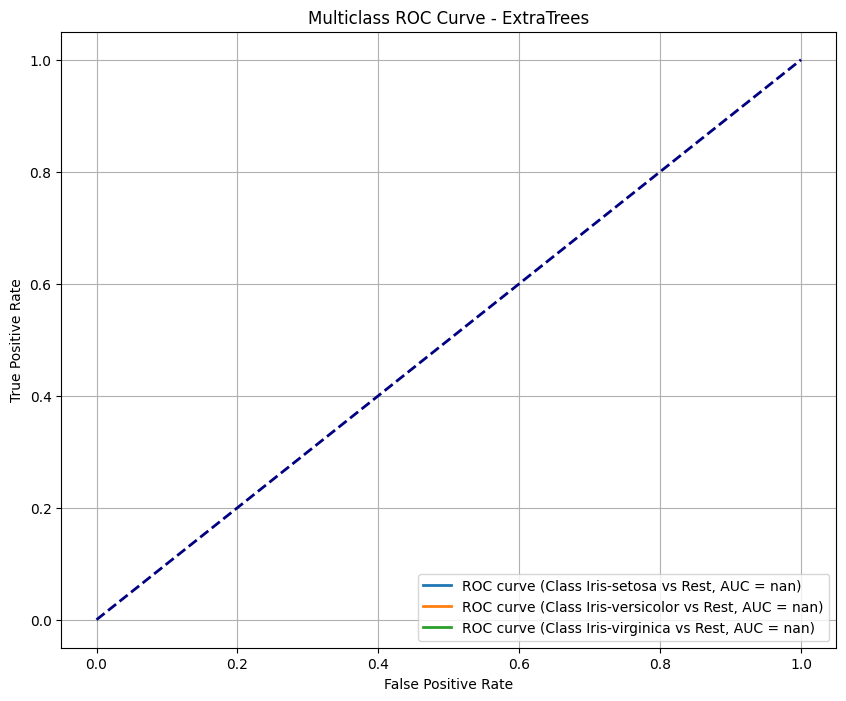

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



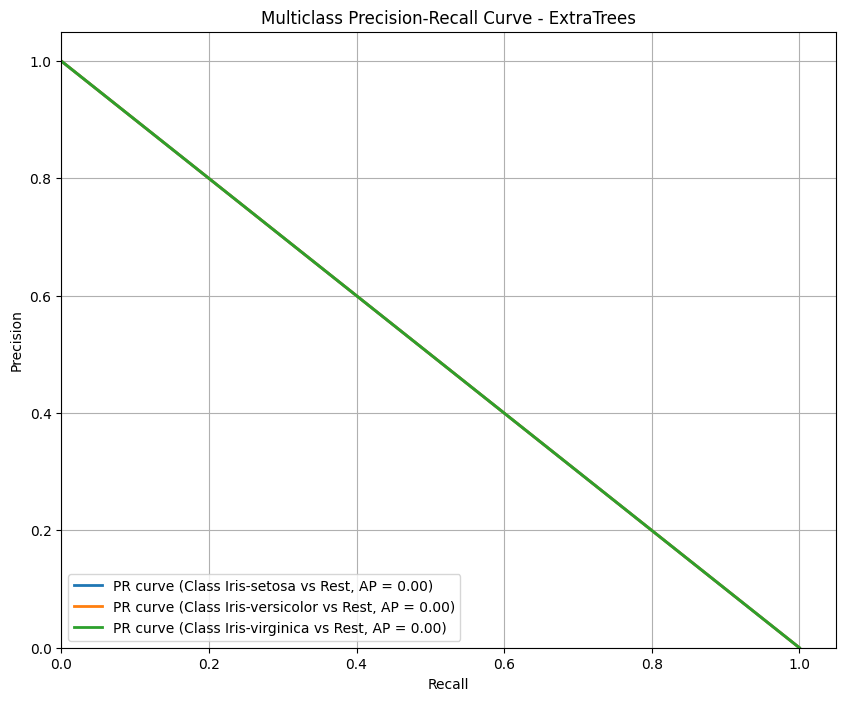


--- Bagging ---
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


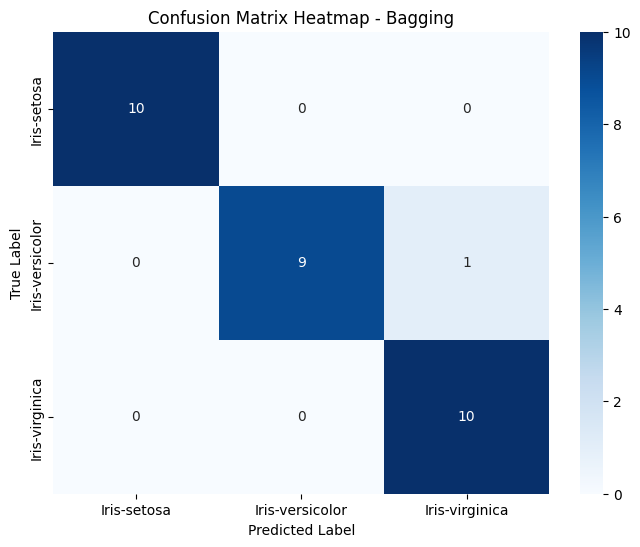

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



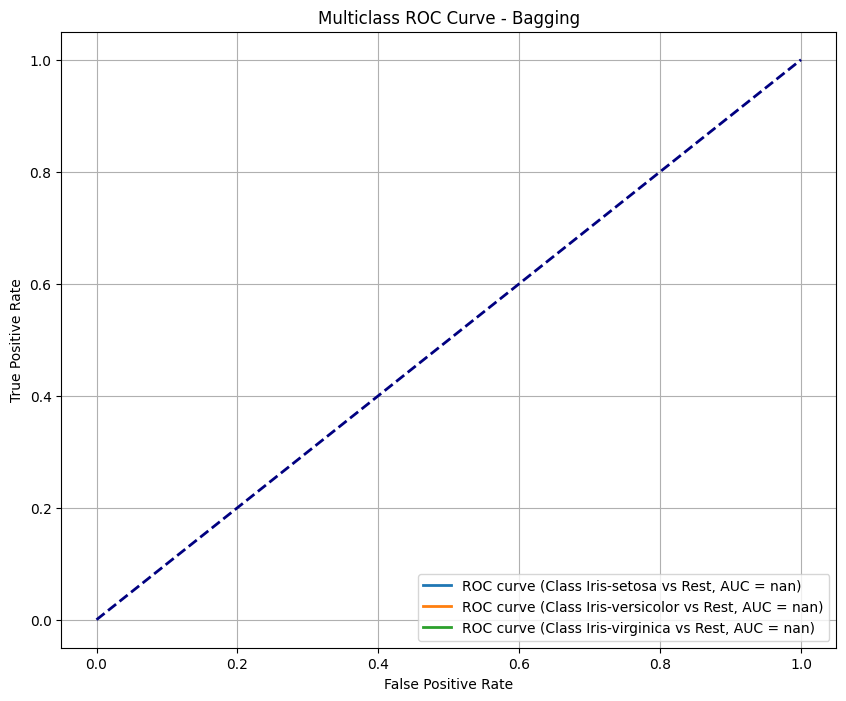

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



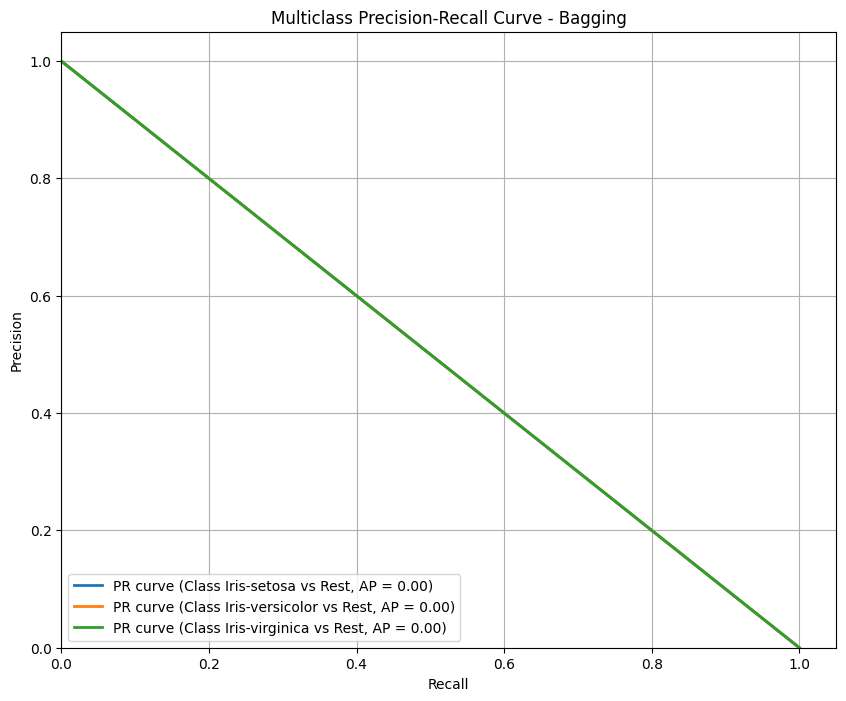


--- ada bosting ---
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


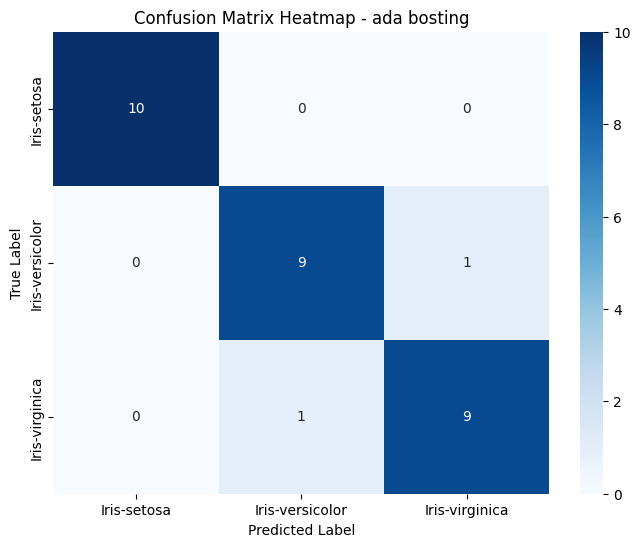

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



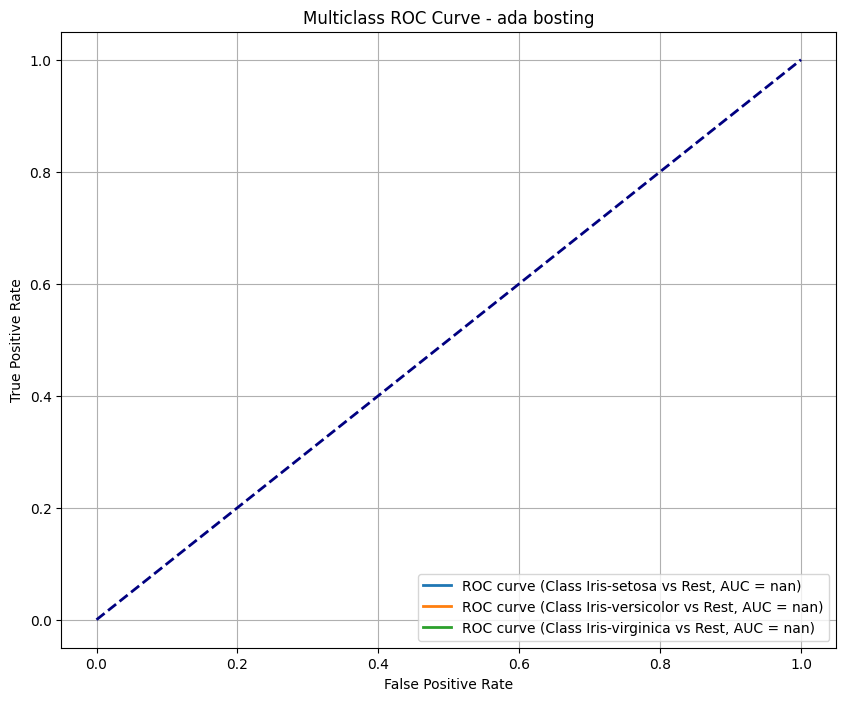

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



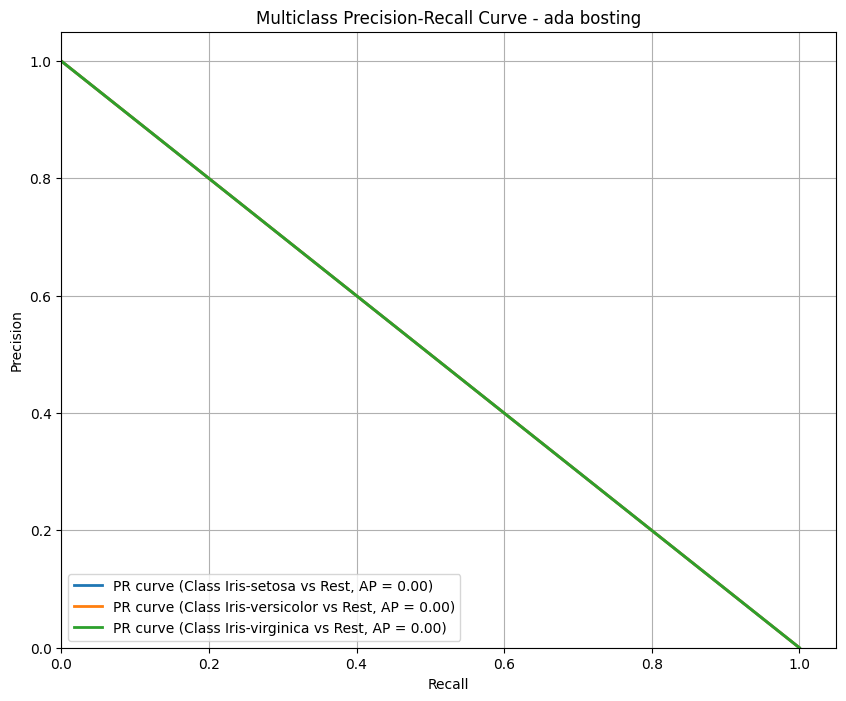


--- Gradient boosting ---
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


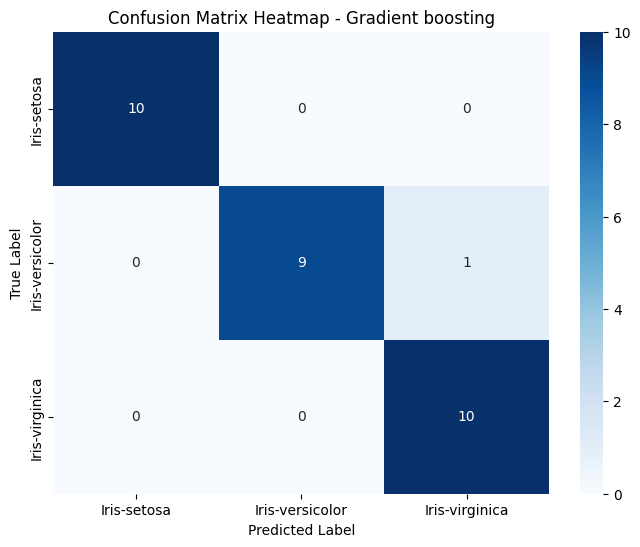

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



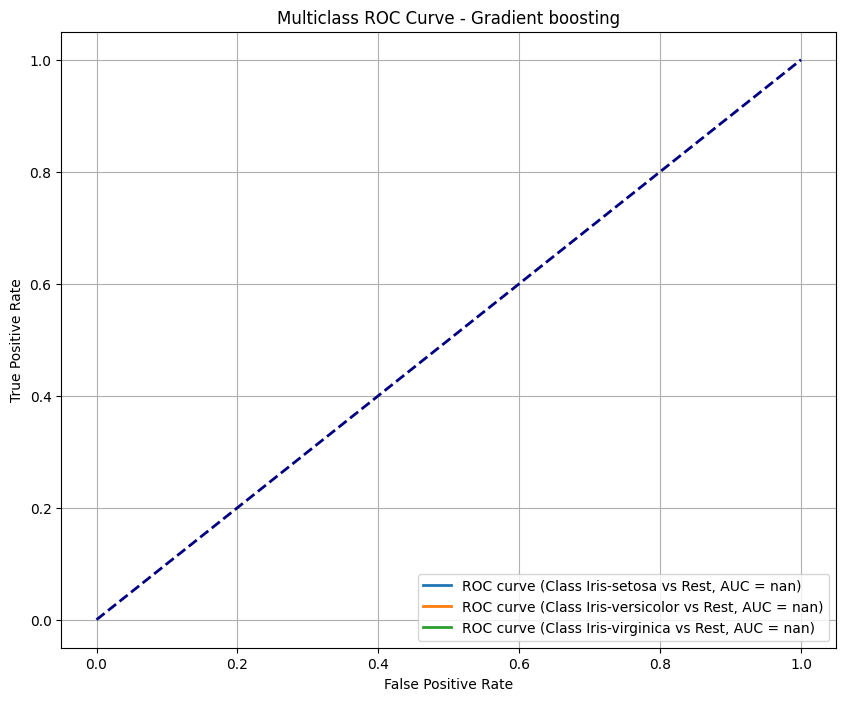

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



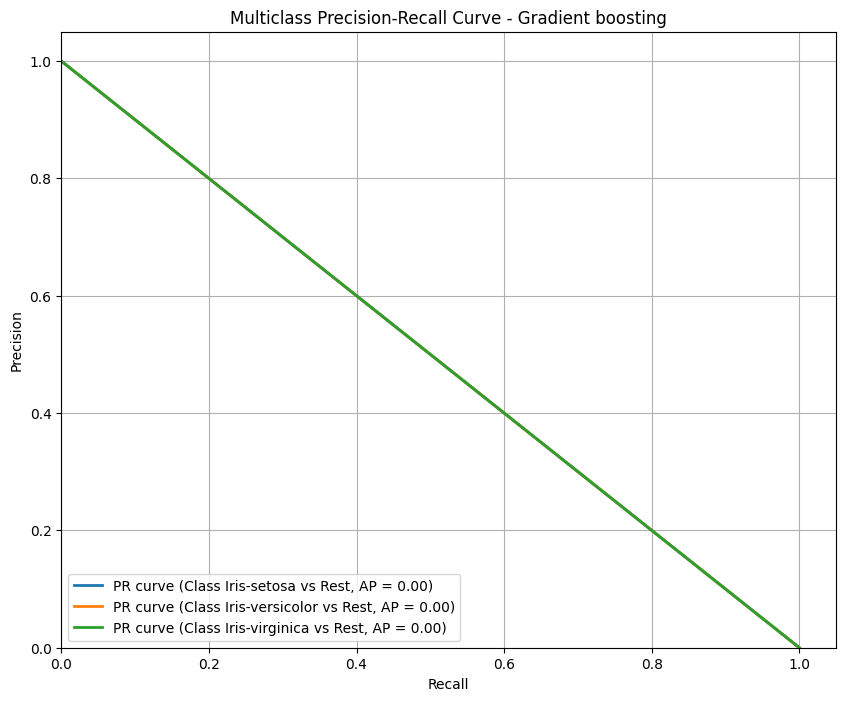


--- HistGradientBoosting ---
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


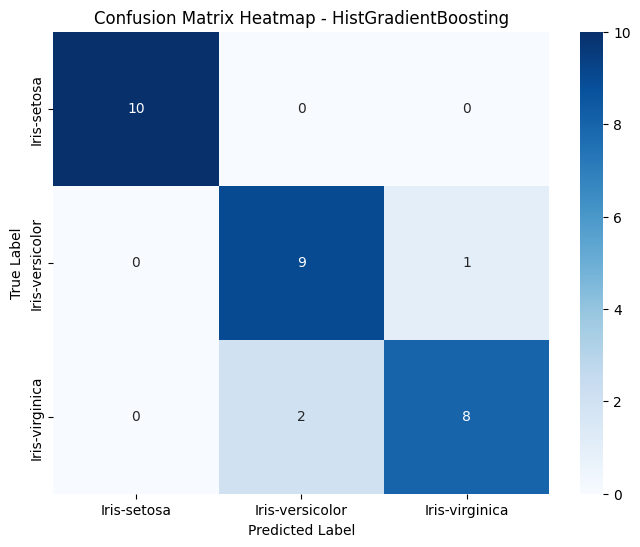

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



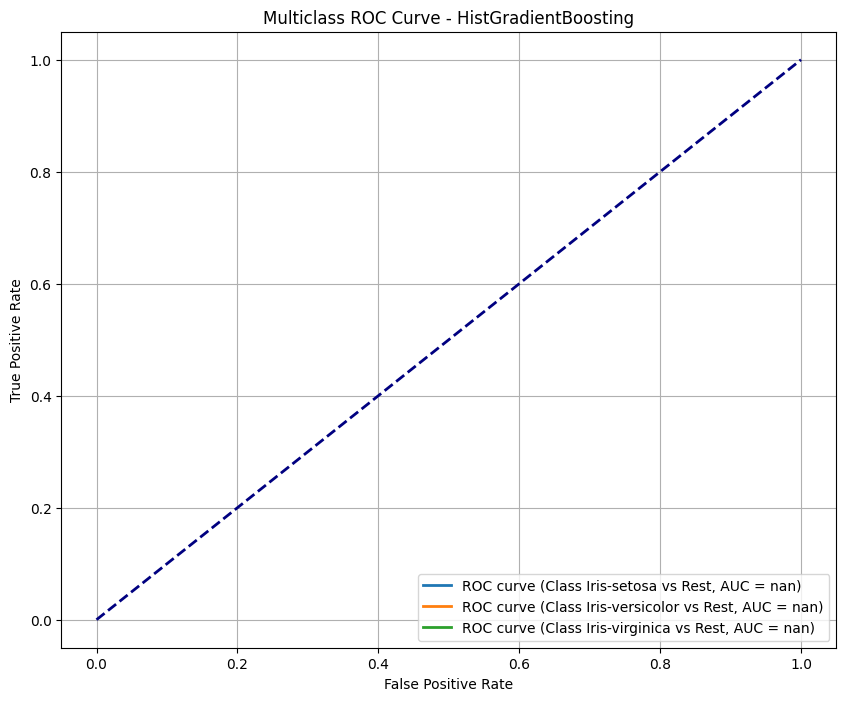

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



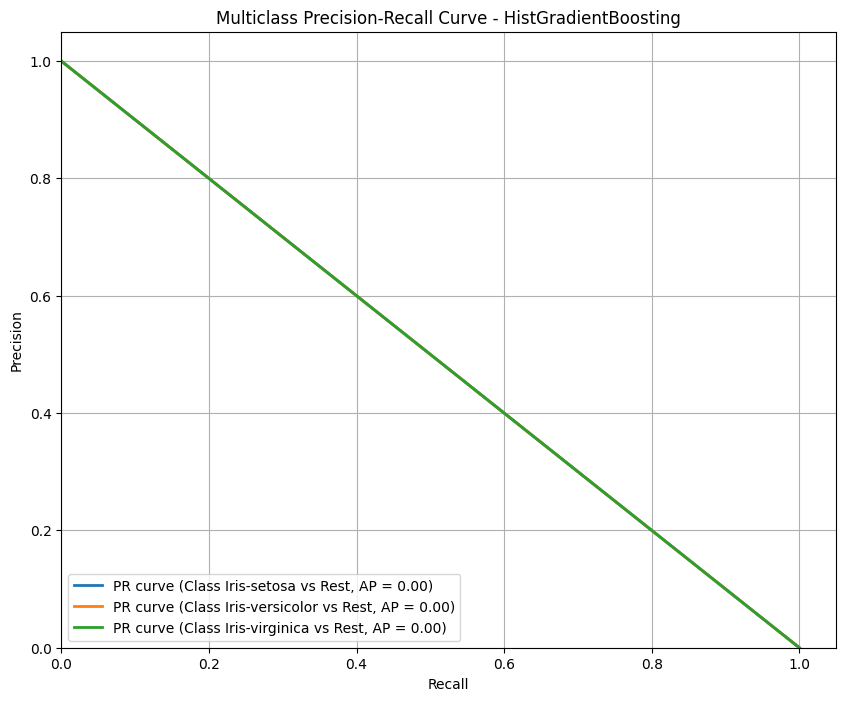


--- CatBoost ---
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


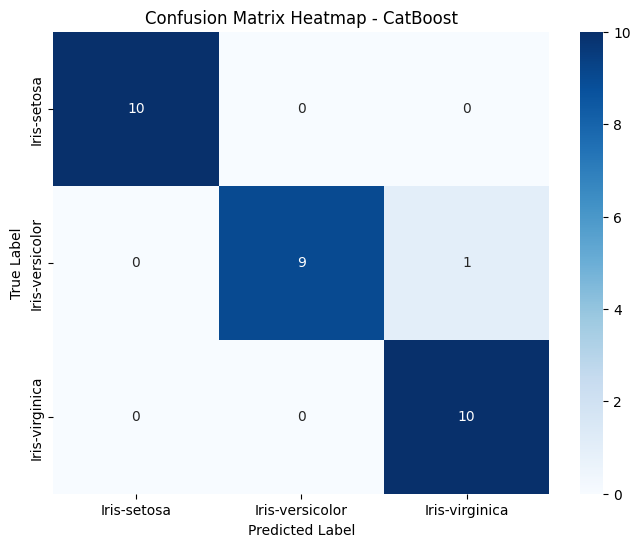

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



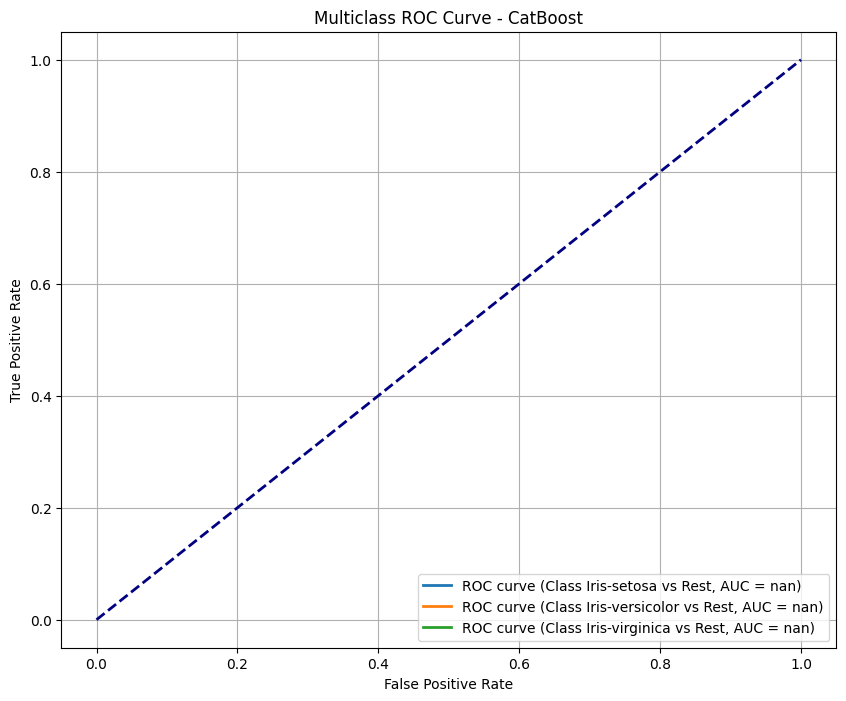

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



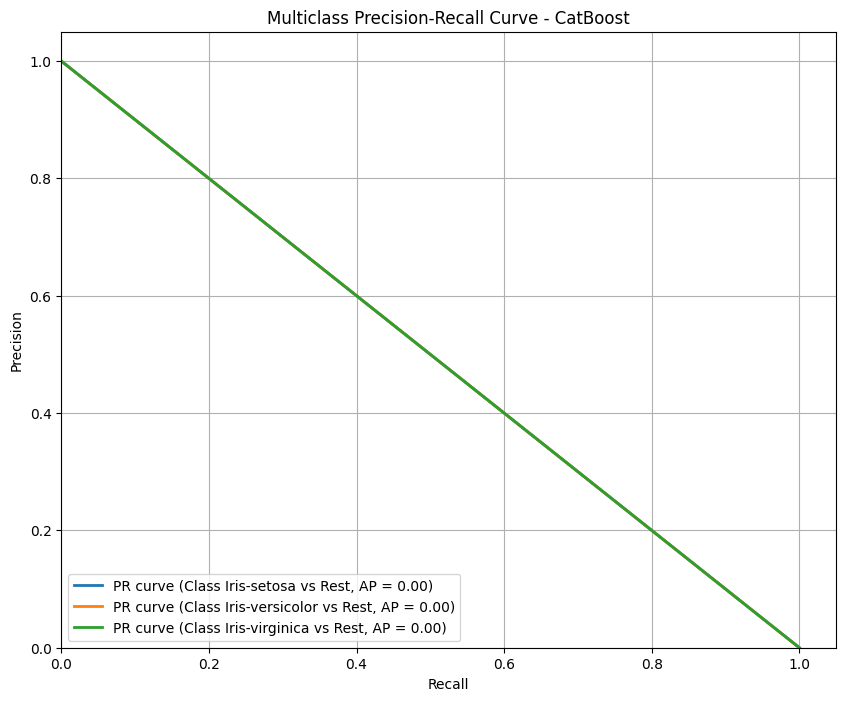

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000192 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 87
[LightGBM] [Info] Number of data points in the train set: 117, number of used features: 4
[LightGBM] [Info] Start training from score -1.124588
[LightGBM] [Info] Start training from score -1.073294
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



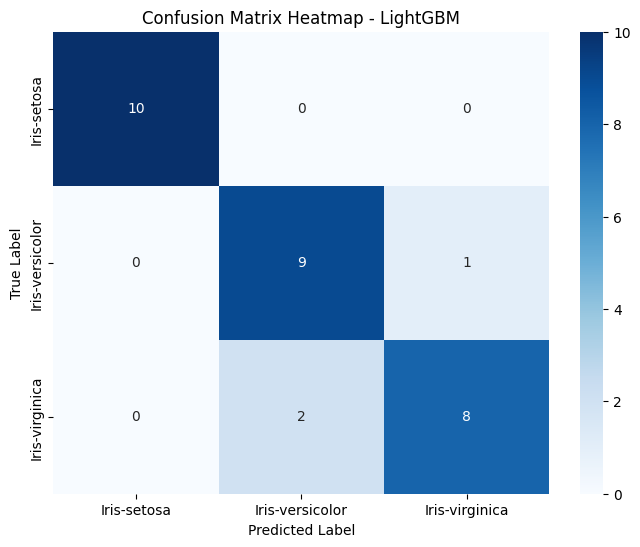

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning:

No positive samples in y_true, true positive value should be meaningless



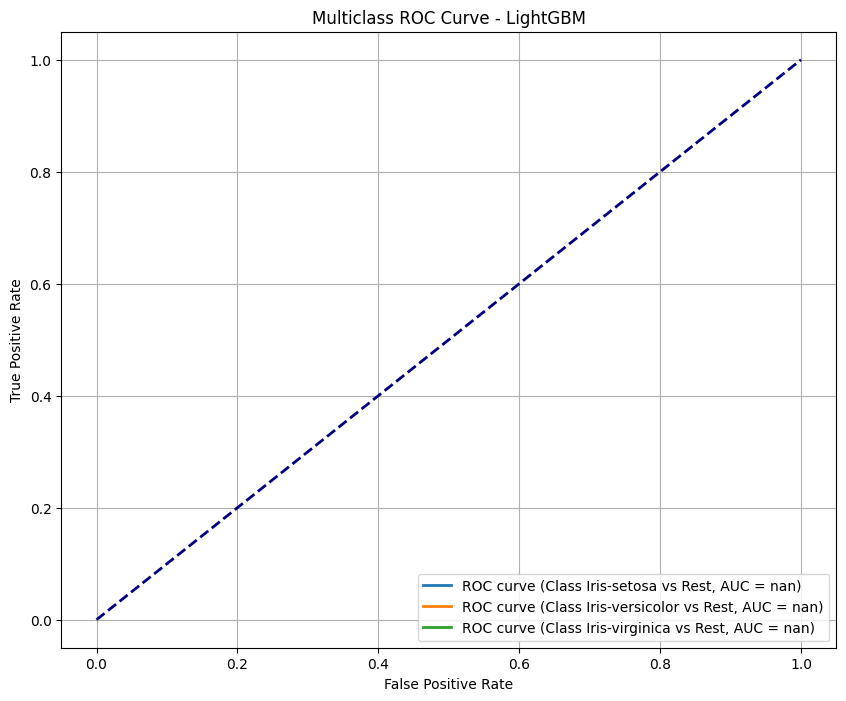

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning:

No positive class found in y_true, recall is set to one for all thresholds.



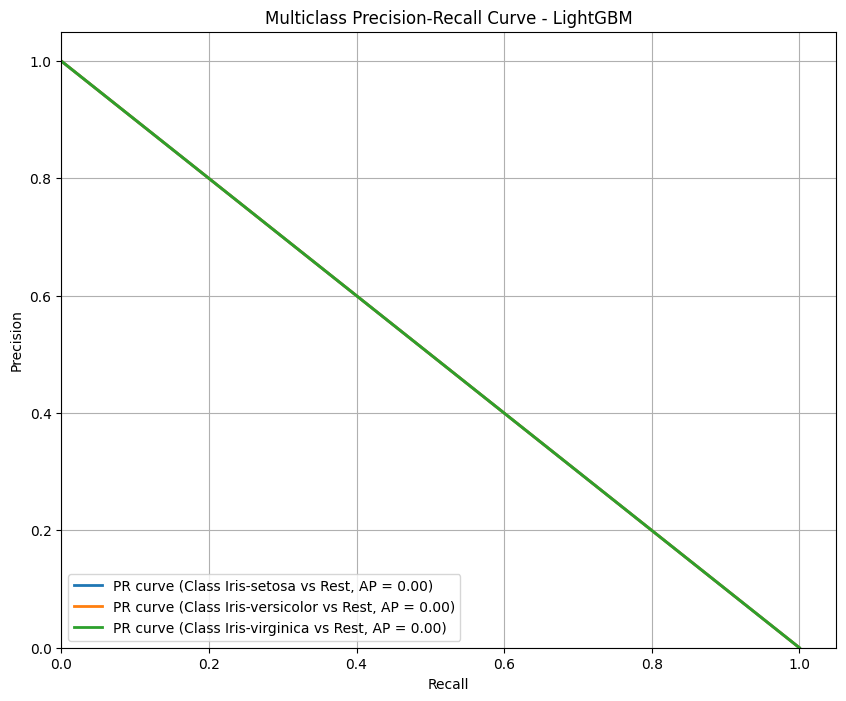

In [136]:
accuracy=[]
for model_name , model in models.items():
    model.fit(x_train,y_train)
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    Acc_Train = accuracy_score(y_train,y_pred_train)
    Acc_Test  =  accuracy_score(y_test,y_pred_test)

    Pre_Train = precision_score(y_train,y_pred_train, average='weighted')
    Pre_Test  =  precision_score(y_test,y_pred_test, average='weighted')

    Rec_Train = recall_score(y_train,y_pred_train, average='weighted')
    Rec_Test  =  recall_score(y_test,y_pred_test, average='weighted')

    F1_Train = f1_score(y_train,y_pred_train, average='weighted')
    F1_Test  =  f1_score(y_test,y_pred_test, average='weighted')

    accuracy.append([Acc_Train,Pre_Train,Rec_Train,F1_Train,Acc_Test,Pre_Test,Rec_Test,F1_Test])

    class_names = le.classes_
    cm = confusion_matrix(y_test,y_pred_test)
    print(f"\n--- {model_name} ---")
    print("Confusion Matrix:")
    print(cm)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix Heatmap - {model_name}')
    plt.show()
    print("Classification Report:")
    print(classification_report(y_test,y_pred_test, target_names=class_names))

    y_probs_all = model.predict_proba(x_test)
    n_classes = len(class_names)

    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test == i, y_probs_all[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'ROC curve (Class {class_names[i]} vs Rest, AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multiclass ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test == i, y_probs_all[:, i])
        ap = average_precision_score(y_test == i, y_probs_all[:, i])
        plt.plot(recall, precision, lw=2, label=f'PR curve (Class {class_names[i]} vs Rest, AP = {ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Multiclass Precision-Recall Curve - {model_name}')
    plt.xlim([0.0, 1.05])
    plt.ylim([0.0, 1.05])
    plt.grid(True)
    plt.legend(loc='lower left')
    plt.show()

In [137]:
pd.DataFrame(accuracy,columns=["Acc_Train","Pre_Train","Rec_Train","F1_Train",
                               "Acc_Test","Pre_Test","Rec_Test","F1_Test"],index=models.keys())

,Acc_Train,Pre_Train,Rec_Train,F1_Train,Acc_Test,Pre_Test,Rec_Test,F1_Test
logistic regression,0.957265,0.957441,0.957265,0.957251,0.933333,0.933333,0.933333,0.933333
GaussianNB,0.957265,0.957441,0.957265,0.957251,0.933333,0.933333,0.933333,0.933333
BernoulliNB,0.769231,0.776801,0.769231,0.751950,0.733333,0.832442,0.733333,0.675485
knn,0.965812,0.965812,0.965812,0.965812,0.933333,0.944444,0.933333,0.932660
svm,0.982906,0.982906,0.982906,0.982906,1.000000,1.000000,1.000000,1.000000
Decision Tree,1.000000,1.000000,1.000000,1.000000,0.933333,0.933333,0.933333,0.933333
Random Forest,1.000000,1.000000,1.000000,1.000000,0.966667,0.969697,0.966667,0.966583
ExtraTrees,1.000000,1.000000,1.000000,1.000000,0.933333,0.933333,0.933333,0.933333
Bagging,1.000000,1.000000,1.000000,1.000000,0.966667,0.969697,0.966667,0.966583
ada bosting,1.000000,1.000000,1.000000,1.000000,0.933333,0.933333,0.933333,0.933333


## svm is the best model

## save best_model
## save scaler
## save encoding

In [138]:
import joblib

In [139]:
joblib.dump(model, 'svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'species_encoder.pkl')

['species_encoder.pkl']